# 4,946 puntos de escombros rocosos atrapados dentro del hielo de Groenlandia

Radar 3D aerotransportado revela estructuras deformadas con rocas elevadas más de 1,000 metros sobre el lecho. Todo apunta a que se formaron hace ~120,000 años, cuando el hielo de Groenlandia se regeneró tras su mínimo del último interglacial.

---

**Paper:** Holschuh, Christianson, Anandakrishnan et al. (2026) — *Nature Geoscience*
**DOI:** [10.1038/s41561-026-01950-1](https://doi.org/10.1038/s41561-026-01950-1)
**Video:** [Ver en YouTube](https://youtube.com/watch?v=7RyzExZhEUs)

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ciencia-a-Mordiscos/lab/blob/main/papers/2026-03-28-rocas-hielo-groenlandia/notebook.ipynb)

## El contexto

El manto de hielo de Groenlandia tiene más de 3 km de espesor en su punto máximo. Debajo, hay roca. Pero entre la roca y el hielo "limpio" hay algo raro: estructuras deformadas llenas de escombros rocosos que el radar detecta como zonas de dispersión anómala.

Un equipo usó radar 3D aerotransportado (técnica MUSIC) para mapear estas estructuras por todo el norte de Groenlandia. El hallazgo: los escombros están **a más de 1,000 m sobre el lecho** — mucho más alto de lo esperado. Y solo aparecen en Groenlandia, no en la Antártida bajo condiciones similares.

La hipótesis: se formaron cuando el hielo se regeneró tras el último interglacial (~120,000 años), avanzando sobre sus propios márgenes congelados y arrastrando rocas hacia arriba.

In [1]:
# ══════════════════════════════════════════════════════════════
# Configuración — modifica estos valores para explorar
# ══════════════════════════════════════════════════════════════
EDAD_INTERGLACIAL = 120_000    # años (MIS 5e)
N_MODELOS_DESTACAR = 3         # Modelos a resaltar en la gráfica de extensiones
FUENTE = 'Fuente: Holschuh et al. (2026), Nature Geoscience | Datos: Harvard Dataverse'
COLOR_DATOS = '#2563EB'        # Azul CaM — escombros
COLOR_ALERTA = '#DC2626'       # Rojo — pérdida de potencia
COLOR_SECUNDARIO = '#059669'   # Emerald
COLOR_REFERENCIA = '#D97706'   # Amber
COLOR_VIOLETA = '#7C3AED'

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import os, urllib.request

# Estilo CaM
style_file = '../../cam.mplstyle'
if not os.path.exists(style_file):
    style_file = '/tmp/cam.mplstyle'
    if not os.path.exists(style_file):
        urllib.request.urlretrieve('https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main/cam.mplstyle', style_file)
plt.style.use(style_file)

# Descargar datos si no existen
os.makedirs('datos', exist_ok=True)
os.makedirs('figuras', exist_ok=True)
archivos = ['trenes_escombros.csv', 'perdida_potencia.csv',
            'extensiones_hielo_mis5e.csv', 'escombros_literatura.csv']
for archivo in archivos:
    if not os.path.exists(f'datos/{archivo}'):
        urllib.request.urlretrieve(f'https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main/papers/2026-03-28-rocas-hielo-groenlandia/datos/{archivo}', f'datos/{archivo}')

# Cargar
df_escombros = pd.read_csv('datos/trenes_escombros.csv')
df_potencia = pd.read_csv('datos/perdida_potencia.csv')
df_modelos = pd.read_csv('datos/extensiones_hielo_mis5e.csv')
df_literatura = pd.read_csv('datos/escombros_literatura.csv')

# Convertir a km para legibilidad
df_escombros['x_km'] = df_escombros.x_m / 1000
df_escombros['y_km'] = df_escombros.y_m / 1000
df_potencia['x_km'] = df_potencia.x_m / 1000
df_potencia['y_km'] = df_potencia.y_m / 1000
df_modelos['x_km'] = df_modelos.x_m / 1000
df_modelos['y_km'] = df_modelos.y_m / 1000

print(f"Trenes de escombros: {len(df_escombros)} ubicaciones")
print(f"Pérdida de potencia: {len(df_potencia)} zonas")
print(f"Modelos MIS 5e: {df_modelos.model.nunique()} modelos")
print(f"Literatura previa: {len(df_literatura)} referencias")

Trenes de escombros: 4946 ubicaciones
Pérdida de potencia: 51 zonas
Modelos MIS 5e: 11 modelos
Literatura previa: 5 referencias


## Veamos dónde aparecen.

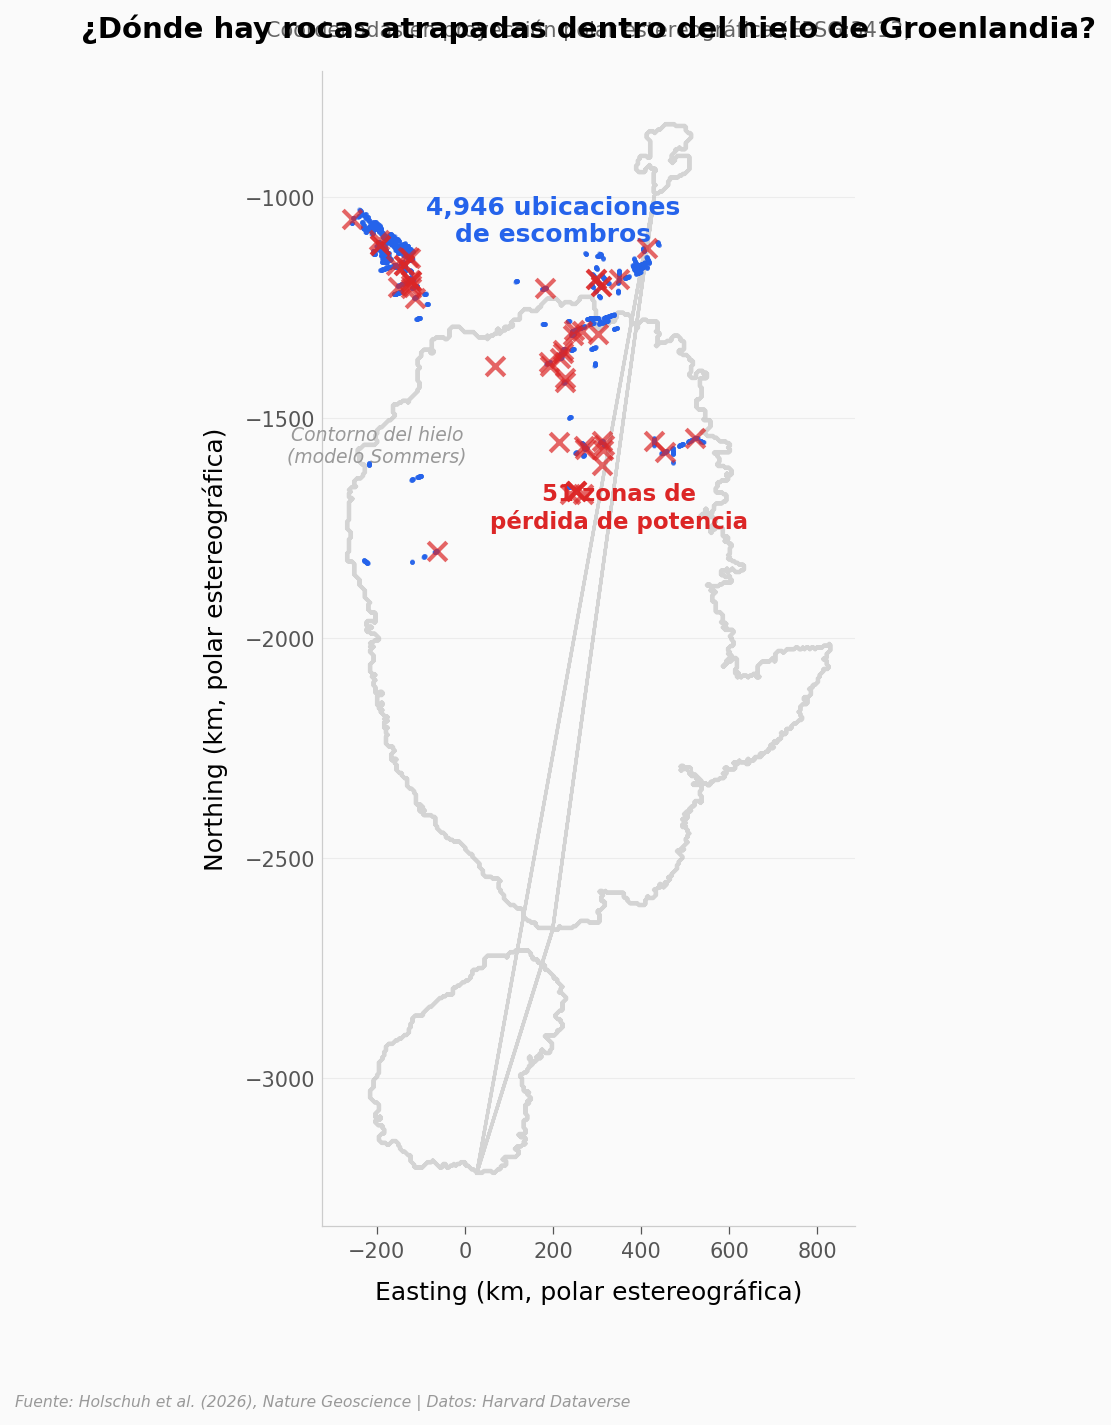

In [2]:
fig, ax = plt.subplots(figsize=(10, 10))

# Plot debris train locations
ax.scatter(df_escombros.x_km, df_escombros.y_km,
           color=COLOR_DATOS, s=3, alpha=0.3, zorder=5)

# Power loss features (larger, red)
ax.scatter(df_potencia.x_km, df_potencia.y_km,
           color=COLOR_ALERTA, s=80, alpha=0.7, marker='x',
           linewidths=2, zorder=6)

# One model outline for context (Sommers — most detailed)
sommers = df_modelos[df_modelos.model == 'Sommers_minimumiceextent']
ax.plot(sommers.x_km, sommers.y_km, color='#BBBBBB', linewidth=1.5,
        alpha=0.6, zorder=3)

# Inline labels
ax.text(200, -1100, f'{len(df_escombros):,} ubicaciones\nde escombros',
        fontsize=12, fontweight='bold', color=COLOR_DATOS, ha='center')
ax.text(350, -1750, f'{len(df_potencia)} zonas de\npérdida de potencia',
        fontsize=11, fontweight='bold', color=COLOR_ALERTA, ha='center')
ax.text(-200, -1600, 'Contorno del hielo\n(modelo Sommers)',
        fontsize=9, color='#999999', ha='center', style='italic')

ax.set_xlabel('Easting (km, polar estereográfica)')
ax.set_ylabel('Northing (km, polar estereográfica)')
ax.set_title('¿Dónde hay rocas atrapadas dentro del hielo de Groenlandia?',
             fontsize=14, fontweight='bold')
ax.text(0.5, 1.03, 'Coordenadas en proyección polar estereográfica (EPSG:3413)',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.set_aspect('equal')

fig.text(0.13, -0.01, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/mapa_escombros.png', dpi=200, bbox_inches='tight')
plt.show()

Cada punto azul es una ubicación donde el radar 3D detectó un "tren de escombros" — una estructura dentro del hielo con material rocoso. Son 4,946 puntos concentrados en el **norte de Groenlandia**, en un área de ~800 × 800 km.

Las cruces rojas son las 51 zonas donde además se detectó pérdida de potencia en el reflector del lecho (la señal del radar se debilita porque los escombros absorben energía). Esto sugiere que no es solo hielo deformado — hay material rocoso real ahí dentro.

El contorno gris es uno de los 11 modelos que estiman cómo era Groenlandia durante el último interglacial.

## Hace 120,000 años, Groenlandia era más pequeña

El hielo de Groenlandia se redujo durante el último interglacial — pero ¿cuánto? Los modelos no se ponen de acuerdo. Veamos los 11 estimados superpuestos con los escombros.

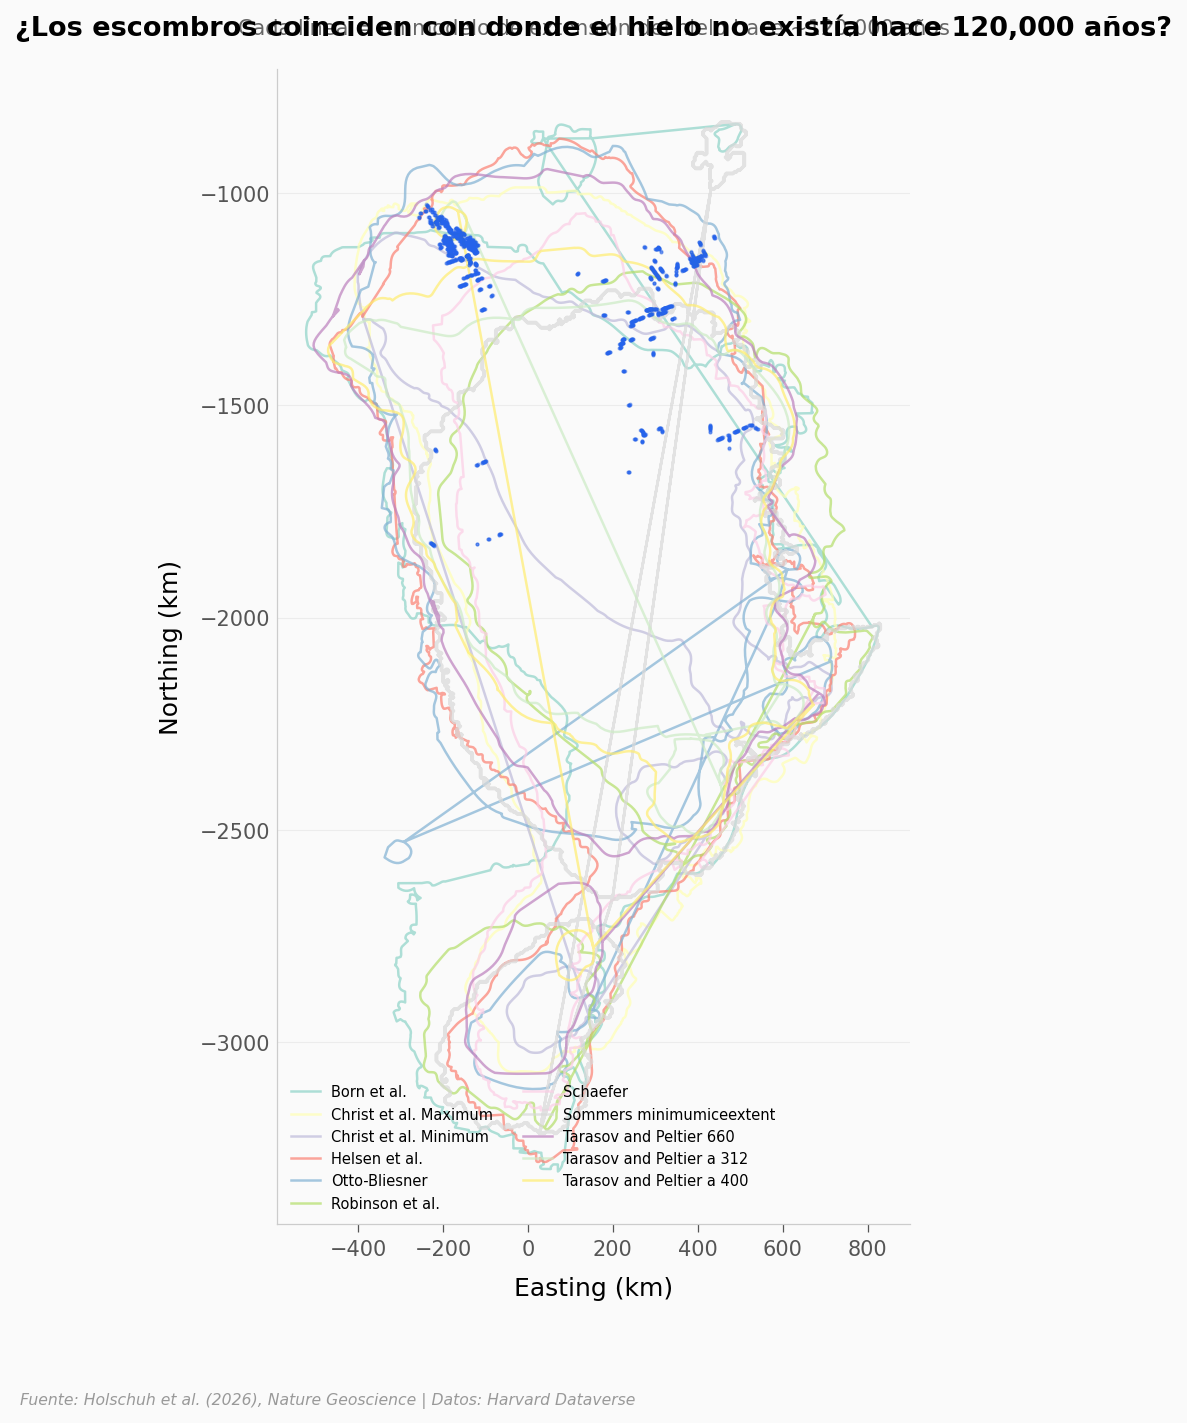

In [3]:
fig, ax = plt.subplots(figsize=(10, 10))

# Plot all model outlines with different colors
model_names = sorted(df_modelos.model.unique())
cmap = plt.cm.Set3(np.linspace(0, 1, len(model_names)))

for i, model in enumerate(model_names):
    sub = df_modelos[df_modelos.model == model]
    # Clean name for display
    label = model.replace('_', ' ').replace('et al', 'et al.')
    ax.plot(sub.x_km, sub.y_km, color=cmap[i], linewidth=1.2, alpha=0.7, label=label)

# Overlay debris trains
ax.scatter(df_escombros.x_km, df_escombros.y_km,
           color=COLOR_DATOS, s=2, alpha=0.15, zorder=5)

ax.set_xlabel('Easting (km)')
ax.set_ylabel('Northing (km)')
ax.set_title('¿Los escombros coinciden con donde el hielo no existía hace 120,000 años?',
             fontsize=13, fontweight='bold')
ax.text(0.5, 1.03, 'Cada línea = un modelo de extensión del hielo hace ~120,000 años',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.set_aspect('equal')
ax.legend(fontsize=7, loc='lower left', framealpha=0.9, ncol=2)

fig.text(0.13, -0.01, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/modelos_extensiones.png', dpi=200, bbox_inches='tight')
plt.show()

Los 11 modelos apuntan en la misma dirección: el norte de Groenlandia tenía menos hielo durante el último interglacial. Y justo ahí es donde están los escombros hoy.

La hipótesis de los autores: cuando el hielo se regeneró, avanzó sobre sus propios márgenes congelados y arrastró rocas del lecho hacia arriba. Si tienen razón, esas rocas llevan atrapadas dentro del hielo 120,000 años.

## ¿Qué tan concentrados están?

Veamos la distribución espacial — ¿los escombros están dispersos uniformemente o se agrupan?

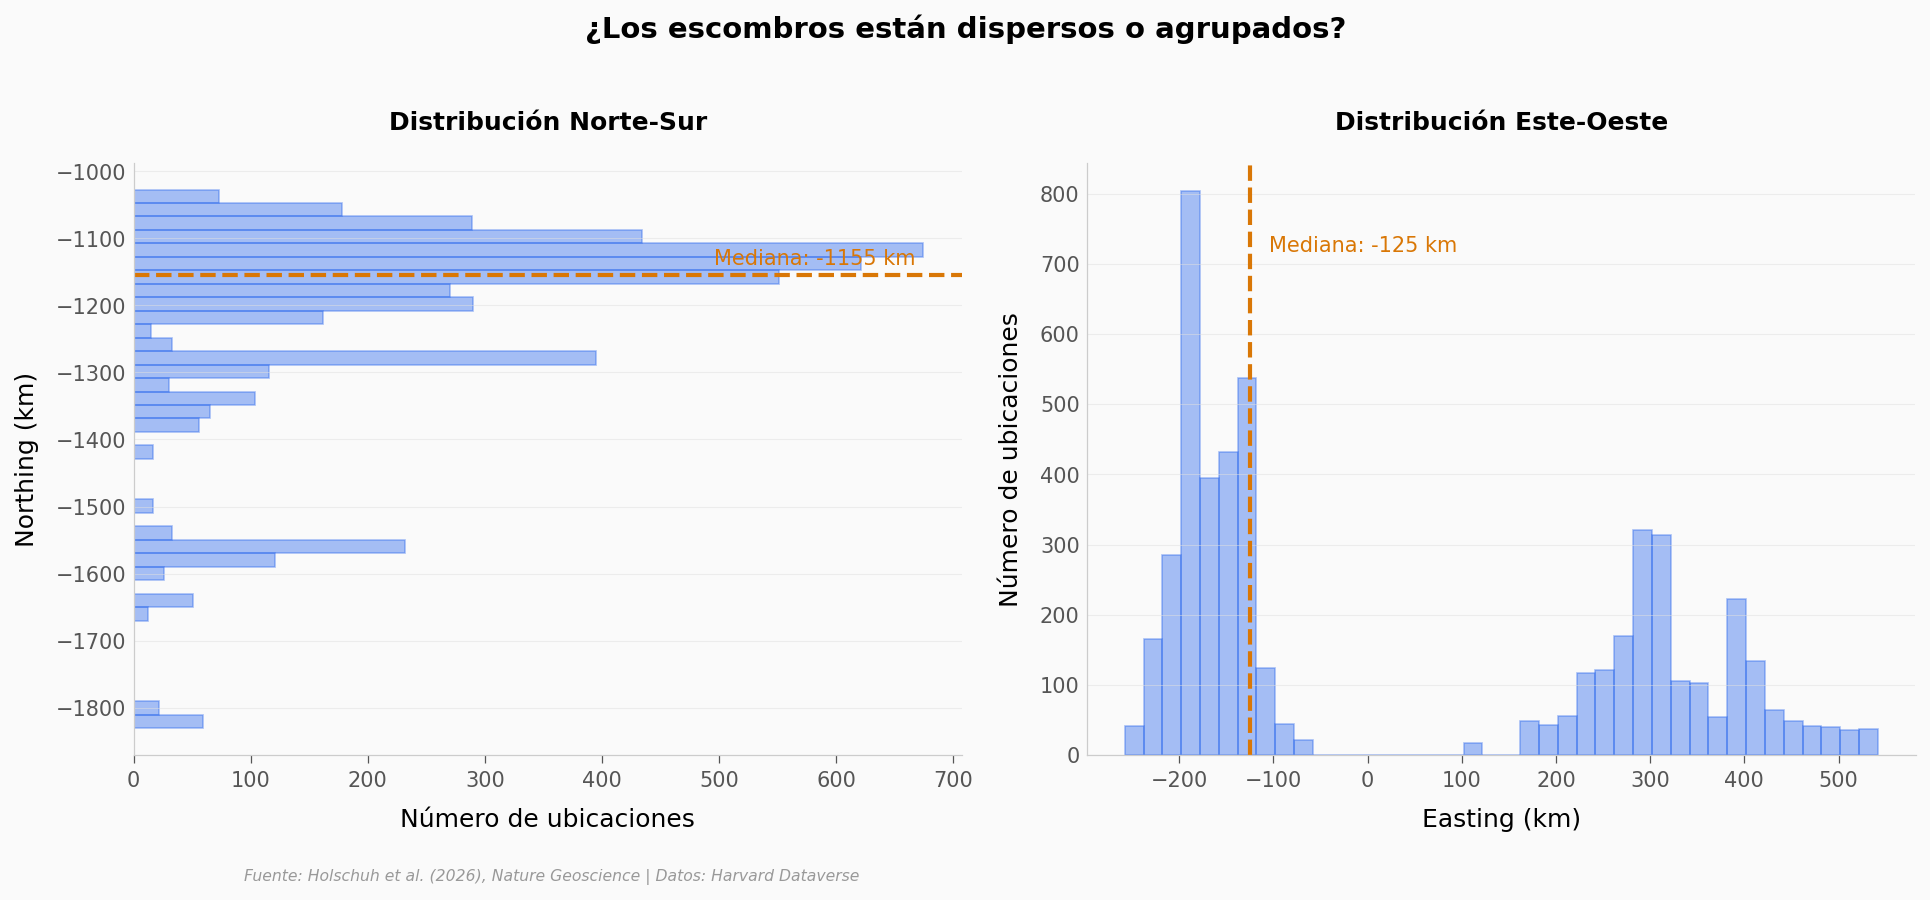

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

# Left: Y distribution (N-S)
axes[0].hist(df_escombros.y_km, bins=40, color=COLOR_DATOS, alpha=0.4,
             edgecolor=COLOR_DATOS, linewidth=0.8, orientation='horizontal')
axes[0].set_ylabel('Northing (km)')
axes[0].set_xlabel('Número de ubicaciones')
axes[0].set_title('Distribución Norte-Sur', fontsize=12, fontweight='bold')

# Add median
median_y = df_escombros.y_km.median()
axes[0].axhline(y=median_y, color=COLOR_REFERENCIA, linewidth=2, linestyle='--')
axes[0].text(axes[0].get_xlim()[1]*0.7, median_y + 15,
             f'Mediana: {median_y:.0f} km', fontsize=10, color=COLOR_REFERENCIA)

# Right: X distribution (E-W)
axes[1].hist(df_escombros.x_km, bins=40, color=COLOR_DATOS, alpha=0.4,
             edgecolor=COLOR_DATOS, linewidth=0.8)
axes[1].set_xlabel('Easting (km)')
axes[1].set_ylabel('Número de ubicaciones')
axes[1].set_title('Distribución Este-Oeste', fontsize=12, fontweight='bold')

median_x = df_escombros.x_km.median()
axes[1].axvline(x=median_x, color=COLOR_REFERENCIA, linewidth=2, linestyle='--')
axes[1].text(median_x + 20, axes[1].get_ylim()[1]*0.85,
             f'Mediana: {median_x:.0f} km', fontsize=10, color=COLOR_REFERENCIA)

plt.suptitle('¿Los escombros están dispersos o agrupados?',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/distribucion_escombros.png', dpi=200, bbox_inches='tight')
plt.show()

Los escombros no están uniformemente distribuidos — se concentran en bandas. La distribución N-S muestra que la mayoría está entre -1,400 y -1,100 km en el eje norte-sur (northing), y hay un pico claro alrededor de -1,100 km.

## ¿Qué tan raro es esto?

En la Antártida, bajo condiciones glaciológicas comparables, nadie ha encontrado trenes de escombros así — aunque la cobertura de radar allí es menor. Veamos cuántos estudios previos los habían documentado.

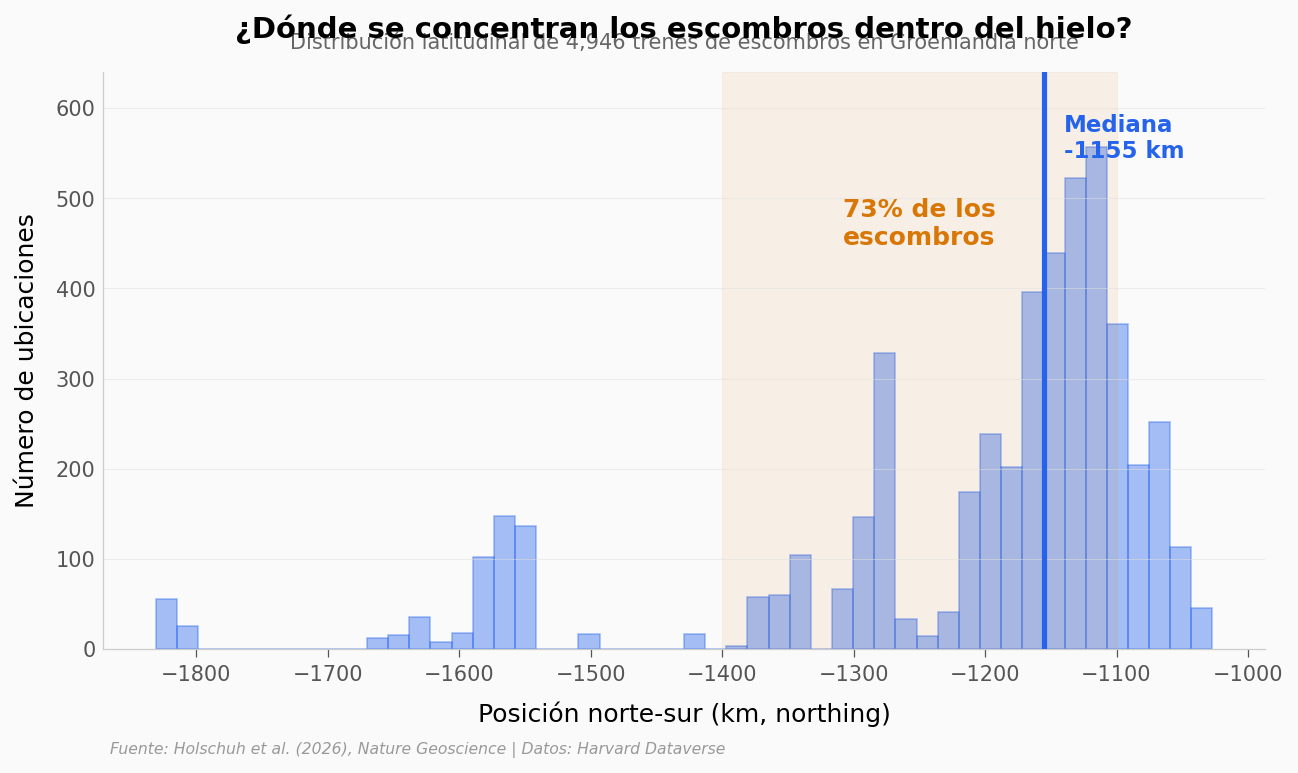

In [5]:
fig, ax = plt.subplots(figsize=(10, 5))

# Histogram of Y positions (N-S) with reference bands
n, bins, patches = ax.hist(df_escombros.y_km, bins=50, color=COLOR_DATOS, alpha=0.4,
                           edgecolor=COLOR_DATOS, linewidth=0.8)

y_max = n.max() * 1.15
ax.set_ylim(0, y_max)

# Median line
median_y = df_escombros.y_km.median()
ax.axvline(x=median_y, color=COLOR_DATOS, linewidth=2.5, zorder=7)
ax.text(median_y + 15, y_max * 0.85, f'Mediana\n{median_y:.0f} km',
        fontsize=11, fontweight='bold', color=COLOR_DATOS)

# Mark the densest zone
ax.axvspan(-1400, -1100, alpha=0.08, color=COLOR_REFERENCIA, zorder=1)
pct_in_range = ((df_escombros.y_km >= -1400) & (df_escombros.y_km <= -1100)).mean() * 100
ax.text(-1250, y_max * 0.7, f'{pct_in_range:.0f}% de los\nescombros',
        fontsize=12, fontweight='bold', color=COLOR_REFERENCIA, ha='center')

ax.set_xlabel('Posición norte-sur (km, northing)')
ax.set_ylabel('Número de ubicaciones')
ax.set_title('¿Dónde se concentran los escombros dentro del hielo?',
             fontsize=14, fontweight='bold')
ax.text(0.5, 1.04, 'Distribución latitudinal de 4,946 trenes de escombros en Groenlandia norte',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/histograma_comparacion.png', dpi=200, bbox_inches='tight')
plt.show()

### Lo que los datos soportan

| Afirmación | ¿Soportada? | Detalle |
|------------|-------------|---------|
| Los escombros son generalizados en el norte de Groenlandia | ✅ | 4,946 ubicaciones en un área de ~800 × 800 km |
| Los escombros están a >1,000 m sobre el lecho | ⚠️ | Los datos disponibles son coordenadas x,y. La elevación viene de los radagramas completos (archivos de 1+ GB no incluidos aquí) |
| Los escombros no aparecen en la Antártida bajo condiciones similares | ⚠️ | 4 estudios previos en Antártida documentaron escombros dispersos, pero no trenes masivos como los 4,946 puntos de este estudio. La cobertura de radar difiere entre continentes, lo que limita la comparación directa |
| Se formaron durante el regrowth post-interglacial (~120 ka) | ⚠️ | Los 11 modelos coinciden en extensión reducida durante MIS 5e, lo cual es consistente con la hipótesis. Pero la datación precisa no viene de estos datos |
| El manto de hielo fue sustancialmente menor durante MIS 5e | ✅ | 11 modelos independientes muestran extensión reducida en el norte — los autores usan "suggest" |

> **Limitaciones:**
> - Los datos aquí son coordenadas 2D (x,y). La información de profundidad y elevación requiere los volúmenes 3D de radar (1-1.5 GB cada uno), no incluidos.
> - Los 51 puntos de pérdida de potencia son una muestra — la cobertura de radar no es uniforme.
> - El paper usa "argue" y "suggest" — la formación durante el regrowth es una hipótesis bien soportada pero no confirmada directamente.
> - La comparación Groenlandia vs Antártida depende de la cobertura de radar disponible en cada continente.

## Ahora tú

Tres preguntas para explorar:

1. **¿Cuántos modelos muestran los escombros FUERA del hielo?** Si los escombros están donde el hielo no existía durante MIS 5e, eso soporta la hipótesis de regrowth. ¿Cuántos de los 11 modelos excluyen la zona de escombros? (Pista: compara el bounding box de los escombros con el bounding box de cada modelo)

2. **¿Los escombros y la pérdida de potencia se solapan?** ¿Las 51 zonas de pérdida de potencia coinciden espacialmente con las 4,946 ubicaciones de escombros, o están en zonas diferentes? (Pista: calcula la distancia mínima de cada punto de pérdida al escombro más cercano)

3. **¿Hay clusters?** ¿Los escombros se agrupan en bandas o están dispersos? (Pista: prueba `scipy.cluster.hierarchy` o simplemente haz un hexbin plot)

In [6]:
# --- EXPERIMENTA AQUÍ ---
# ¿Los puntos de pérdida de potencia coinciden con los escombros?

from scipy.spatial import cKDTree

# Build tree of debris train locations
tree = cKDTree(df_escombros[['x_km', 'y_km']].values)

# For each power loss point, find distance to nearest debris train
distances, indices = tree.query(df_potencia[['x_km', 'y_km']].values)

print("Distancia de cada punto de pérdida al escombro más cercano:")
print("=" * 50)
print(f"  Mediana: {np.median(distances):.1f} km")
print(f"  Media:   {np.mean(distances):.1f} km")
print(f"  Máx:     {np.max(distances):.1f} km")
print(f"  Mín:     {np.min(distances):.1f} km")
print(f"\n  Puntos a < 10 km: {(distances < 10).sum()} / {len(distances)}")
print(f"  Puntos a < 50 km: {(distances < 50).sum()} / {len(distances)}")

Distancia de cada punto de pérdida al escombro más cercano:
  Mediana: 0.1 km
  Media:   7.6 km
  Máx:     115.7 km
  Mín:     0.0 km

  Puntos a < 10 km: 42 / 51
  Puntos a < 50 km: 50 / 51


---

## Créditos

- **Paper:** Holschuh, Christianson, Anandakrishnan et al. (2026). *Entrained debris records regrowth of the Greenland Ice Sheet after the last interglacial.* Nature Geoscience.
- **DOI:** [10.1038/s41561-026-01950-1](https://doi.org/10.1038/s41561-026-01950-1)
- **Datos:** [Harvard Dataverse](https://doi.org/10.7910/DVN/9K2J6R) — coordenadas de trenes de escombros, pérdida de potencia, y extensiones de hielo
- **Código original:** [github.com/nholschuh/DebrisTrains](https://github.com/nholschuh/DebrisTrains)
- **Licencia datos:** Harvard Dataverse (CC0 1.0)
- **Repo:** [github.com/Ciencia-a-Mordiscos/lab](https://github.com/Ciencia-a-Mordiscos/lab)